In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import(
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

In [ ]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
print(df["gender"].dtype)

int64


In [ ]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].mean())

In [ ]:
# SimpleImputer(strategy="mean") fills missing numerical values with the average value of that column.
imputer=SimpleImputer(strategy="mean")
df["TotalCharges"]=imputer.fit_transform(df[["TotalCharges"]])
# fit()       → calculates the mean of the column
# transform() → replaces NaN values with that mean
# fit_transform() → does both steps together

In [ ]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [ ]:
# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Columns:")
print(num_cols)

# Text/Categorical columns
cat_cols = df.select_dtypes(include=['object', 'string', 'category']).columns
print("Categorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
Categorical Columns:
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


In [ ]:
# Loop through every column in cat_cols.
# Check how many unique values each column has using nunique().
# If a column has exactly 2 unique values (== 2),
# include it in the binary_cols list.
binary_cols = [col for col in cat_cols if df[col].nunique() == 2]

# Loop through every column in cat_cols.
# Check how many unique values each column has using nunique().
# If a column has more than 2 unique values (> 2),
# include it in the multi_cols list.
multi_cols = [col for col in cat_cols if df[col].nunique() > 2]

# Print all columns identified as binary columns.
print("Binary:", binary_cols)

# Print all columns identified as multi-category columns.
print("Multi-category:", multi_cols)

Binary: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
Multi-category: ['customerID', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [ ]:
# Drop useless column
df.drop("customerID",axis=1,inplace=True)

In [ ]:
# List of columns that contain only two categories (binary values)
# Examples: Yes/No, Male/Female
binary_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]

# Create a LabelEncoder object
# LabelEncoder converts text labels into numerical values
# Example: Yes -> 1, No -> 0
le = LabelEncoder()

# Loop through each binary column
for col in binary_cols:

    # fit_transform() performs two tasks:
    # 1. fit()    -> learns the unique categories in the column
    # 2. transform() -> converts those categories into numbers
    #
    # Example:
    # Male, Female, Male
    # becomes
    # 1, 0, 1
    #
    # We use Label Encoding because these columns have only 2 categories.
    df[col] = le.fit_transform(df[col])


# List of columns containing more than two categories
# These are called multi-category categorical features
multi_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

# Apply One-Hot Encoding to multi-category columns
# get_dummies() creates separate binary columns for each category
#
# Example:
# InternetService
# DSL
# Fiber optic
# No
#
# becomes:
# InternetService_Fiber optic
# InternetService_No
#
# columns=multi_cols:
# specifies which columns to encode
#
# drop_first=True:
# removes one category from each feature to avoid
# Dummy Variable Trap (multicollinearity)
# and reduces unnecessary columns.
df = pd.get_dummies(
    df,
    columns=multi_cols,
    drop_first=True
)

# Display first 5 rows of the transformed dataset
# Used to verify that encoding was applied correctly
print(df.head())

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0                 1           29.85         29.85      0  ...   
1                 0           56.95       1889.50      0  ...   
2                 1           53.85        108.15      1  ...   
3                 0           42.30       1840.75      0  ...   
4                 1           70.70        151.65      1  ...   

   TechSupport_Yes  StreamingTV_No internet service  StreamingTV_Yes  \
0            False                            False            False   
1            False                    

In [ ]:
# Feature X and Target y

# Feature x
X=df.drop("Churn",axis=1)

# Target variable
y=df["Churn"]

print("X shape: ",X.shape)
print("y shape: ",y.shape)

X shape:  (7043, 30)
y shape:  (7043,)


In [ ]:
# Train Test Split
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model=LogisticRegression()


In [ ]:
# train the model
model.fit(X_train,y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
# predict
y_pred=model.predict(X_test)
print("\nPrediction: ")
print(y_pred)


Prediction: 
[1 0 0 ... 0 0 0]


In [ ]:
# Predict Probability
probabilities=model.predict_proba(X_test)
print("\nProbability Prediction: ")
print(probabilities)


Probability Prediction: 
[[0.31053203 0.68946797]
 [0.93695677 0.06304323]
 [0.99538689 0.00461311]
 ...
 [0.9486991  0.0513009 ]
 [0.98661857 0.01338143]
 [0.51277573 0.48722427]]


In [ ]:
# Confusion Matrix
cm=confusion_matrix(y_test,y_pred)
print("\nConfusion Matrix: ")
print(cm)


Confusion Matrix: 
[[934 102]
 [151 222]]


In [ ]:
# Accuracy Score
acc=accuracy_score(y_test,y_pred)
print("\nAccuracy Score: ")
print(acc)


Accuracy Score: 
0.8204400283889283


In [ ]:
# Precision
precision=precision_score(y_test,y_pred)
print("\nPrecision Score: ")
print(precision)


Precision Score: 
0.6851851851851852


In [ ]:
# Recall
recall=recall_score(y_test,y_pred)
print("\nRecall Score: ")
print(recall)


Recall Score: 
0.5951742627345844


In [ ]:
# F1 Score
f1=f1_score(y_test,y_pred)
print("\nF1 Score: ")
print(f1)


F1 Score: 
0.6370157819225251


In [ ]:
from sklearn.metrics import classification_report

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



In [ ]:
# New customer data
new_customer = pd.DataFrame([[
    0,0,1,0,1,1,12,70.5,850.2,
    1,0,1,0,0,0,1,0,1,0,0,
    0,1,0,1,0,0,0,1,0,0
]], columns=X.columns)

# Scale
new_customer_scaled = scaler.transform(new_customer)

# Predict probability
probability = model.predict_proba(new_customer_scaled)

print("Not Churn Probability:", probability[0][0])
print("Churn Probability:", probability[0][1])

if probability[0][1] > 0.5:
    print("Customer will churn")
else:
    print("Customer will not churn")

Not Churn Probability: 0.023647634536108186
Churn Probability: 0.9763523654638918
Customer will churn


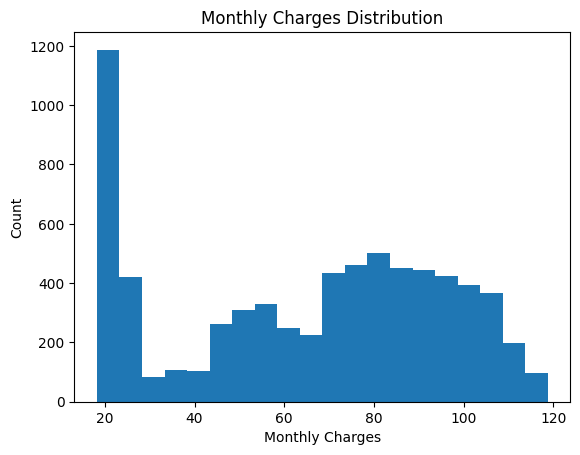

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df["MonthlyCharges"],bins=20)
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Count")
plt.show()


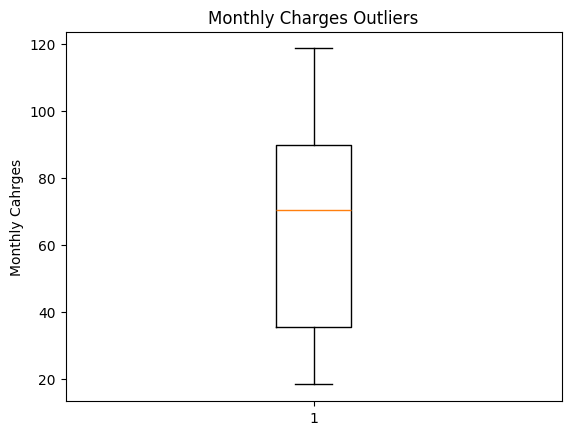

In [ ]:
plt.boxplot(df["MonthlyCharges"])
plt.title("Monthly Charges Outliers")
plt.ylabel("Monthly Cahrges")
plt.show()

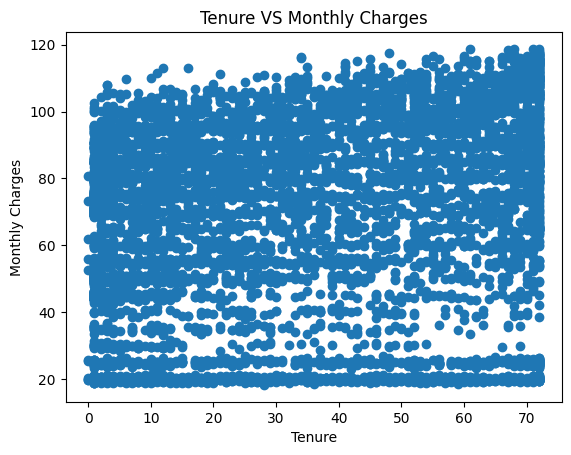

In [ ]:
plt.scatter(df["tenure"],df["MonthlyCharges"])
plt.title("Tenure VS Monthly Charges")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.show()


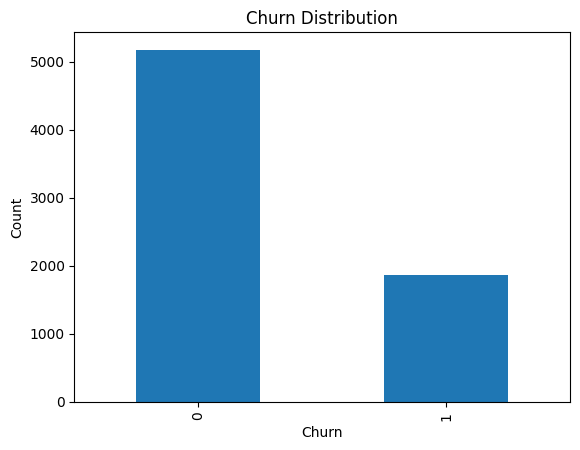

In [ ]:
df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

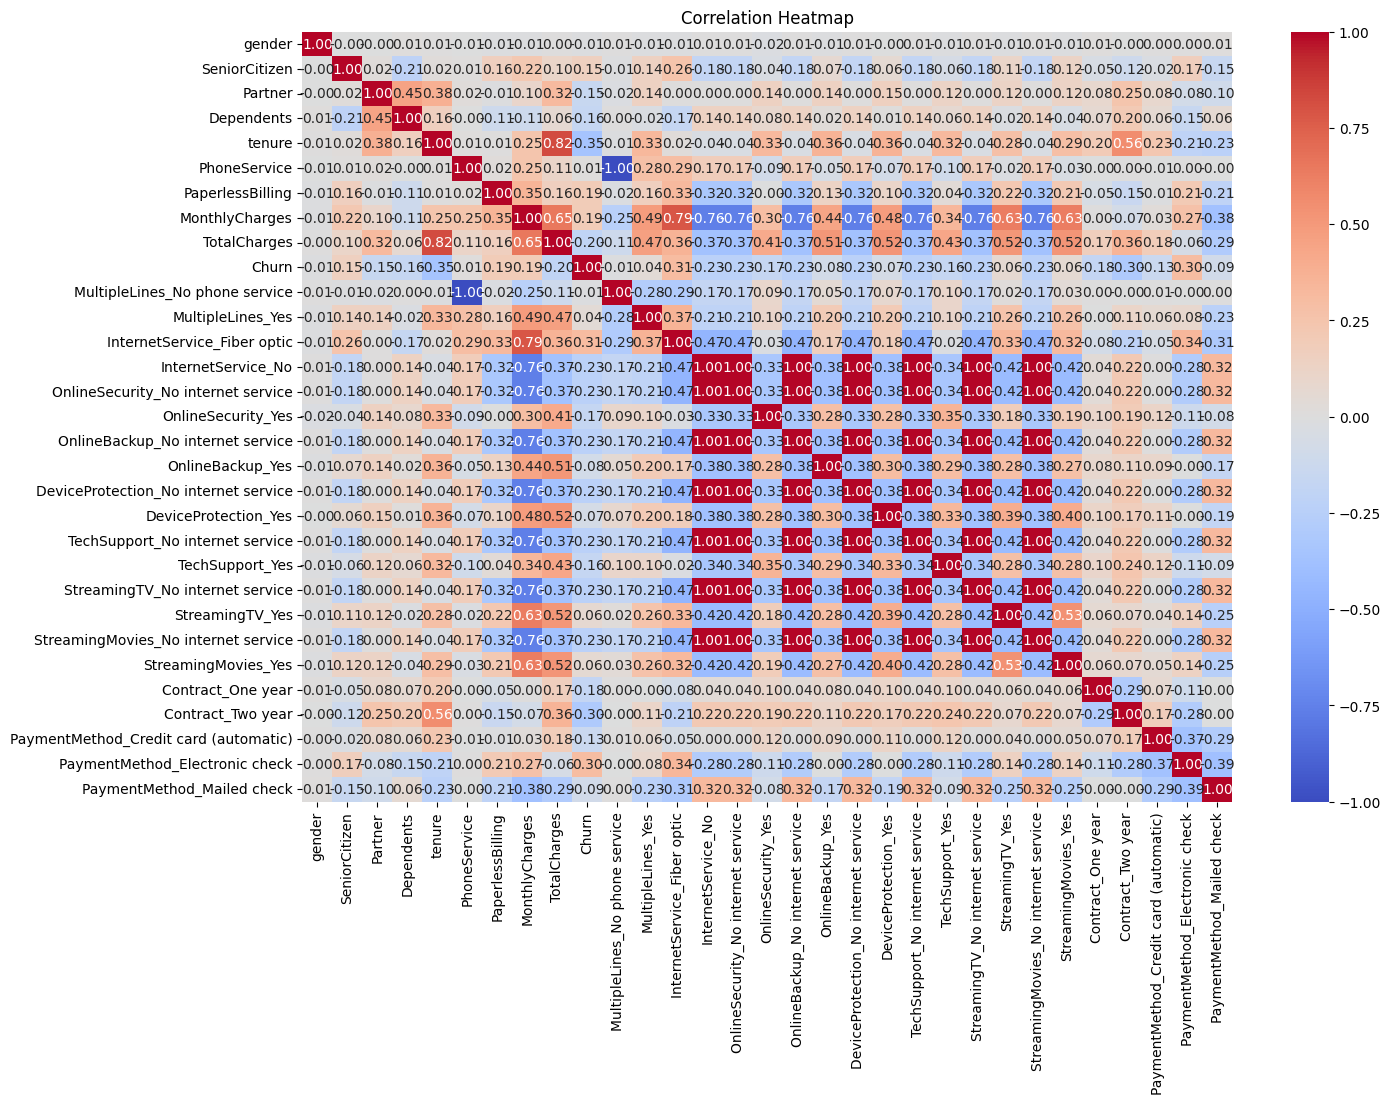

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()